![imagen](./img/seaborn.png)


# Exploratory Data Analysis with Seaborn
Entender cómo se hacen las gráficas en python está muy bien, pero lo importante es saber cuándo usarlas. En este notebook no se pretende explicar todos los tipos de gráficas que hay (histogramas, scatter plots, heatmaps...), en primer lugar porque es imposible abarcarlo todo, y en segundo lugar porque hay que ir un paso atrás antes de elegir la gráfica, ya que tenemos que comprender de qué tipo son los datos y qué es lo que estamos buscando con cada gráfica.

Por tanto, primero tendremos que identificar el tipo de los datos y cuántas variables vamos a representar
- Una variable numérica
- Una variable categórica
- Dos variables numéricas
- Tres o más variables numéricas
- Dos variables categóricas
- Variables numéricas y categóricas

Teniendo claro esto, junto con un buen catálogo de gráficas, lo tendremos mucho más fácil.

https://www.data-to-viz.com/

# Tipos de las variables
Antes de representar cualquier variable es imprescindible comprender qué tipo de datos queremos representar. Tenemos los siguientes:

![imagen](./img/dtypes.png)

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importamos todos los paquetes que vayamos a necesitar
from sklearn.datasets import load_iris
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Algunas configuraciones de los paquetes
pd.set_option("display.max_rows", 500) # Cuántas filas de los DataFrames nos "escupe" pandas en el Notebook
sns.set_theme(color_codes=True)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Cargamos las features en un DataFrame:
iris_df = pd.DataFrame(load_iris()["data"],columns=load_iris()["feature_names"])
boston_df = pd.read_csv('data/boston_house_prices.csv', header=1)

# Y añadimos la columna de especies:
iris_df["target"] = load_iris()["target_names"][load_iris()["target"]]

# Cargamos tb el dataset del titanic
titanic_df = pd.read_csv("data/titanic.csv", sep="\t")

# Cargamos los datos del supermarket sales
market_df = pd.read_csv("data/supermarket_sales.csv")

# Cargamos dataset de suicidios
suicid_df = pd.read_csv("data/suicide.csv")

In [4]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
market_df.head()

In [ ]:
iris_df.head()

In [ ]:
suicid_df.head()

## 1. Análisis univariante
### 1.1 Variables cuantitativas
Si queremos ver cómo se distribuyen los precios de venta de tickets del Titanic.
#### Densidad

[Documentación](https://seaborn.pydata.org/generated/seaborn.distplot.html)

Este tipo de gráficas nos sirven para ver la distribución de los datos, donde se concentran más, ¿es dispersa? ¿tiene asimétría? ¿por qué? ¿Hay outliers?

In [6]:
titanic_df['Fare'].min()

np.float64(6.75)

In [7]:
titanic_df['Fare'].max()

np.float64(263.0)

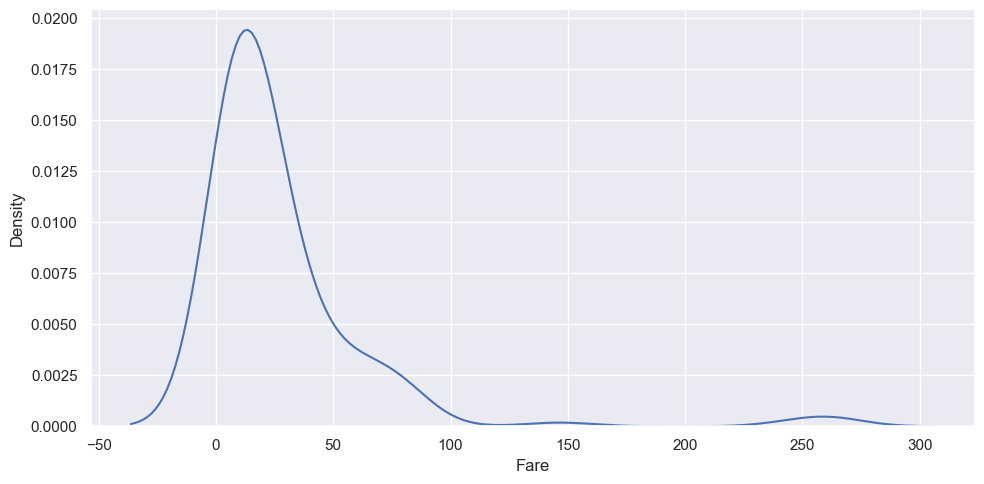

In [8]:
# plt.figure(figsize=(10,5))
# sns.distplot(titanic_df["Fare"], hist = False);
sns.displot(titanic_df["Fare"], kind="kde", height=5, aspect=2);
#plt.title("My KDE")
# plt.xlim(0,50)

#### Histograma
También podemos verlo en un histograma

[Documentación](https://seaborn.pydata.org/generated/seaborn.distplot.html)

Los histogramas dan la frecuencia de aparición de todos los valores. Muy similar al diagrama de densidad anterior. La diferencia es que ahora el eje y es un conteo y no la probabilidad de aparición de los valores de la variable.

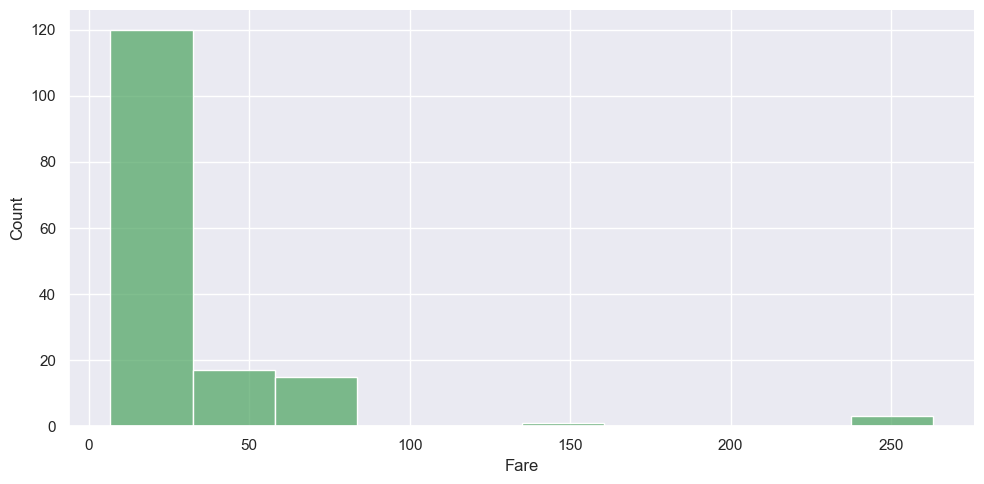

In [9]:
sns.displot(titanic_df["Fare"],
            kind="hist",
            color='g',
            bins=10,
            height=5, 
            aspect=2);
# plt.xlim(0,30)
# plt.ylim(0,20)

Podemos agrupar (visualmente) una variable numérica. Podría ser una posible categorización de los billetes

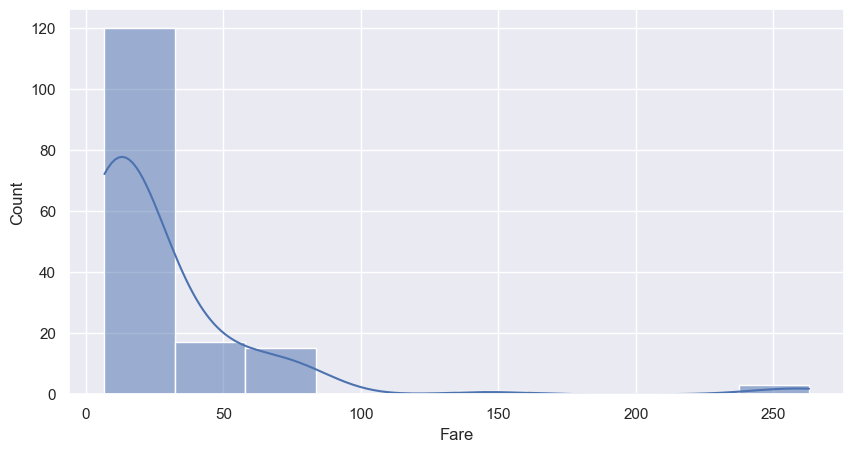

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(titanic_df["Fare"],
            kde=True,
            bins=10);

#### Histograma + Densidad

[Documentación](https://seaborn.pydata.org/generated/seaborn.distplot.html)

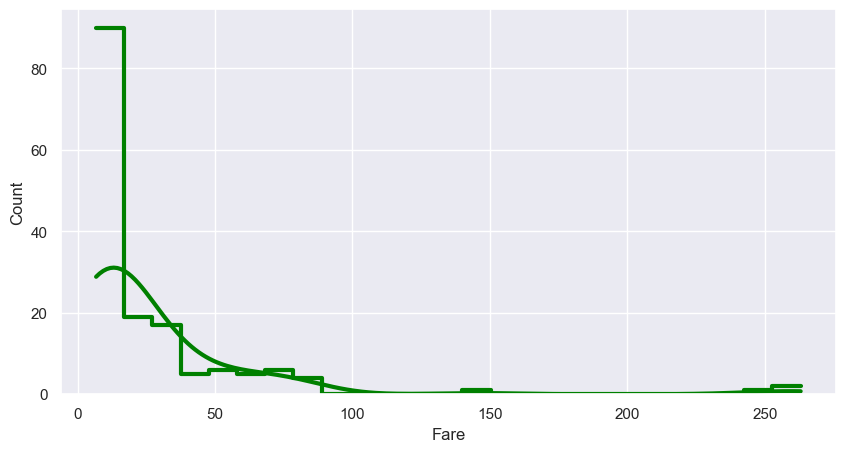

In [11]:
plt.figure(figsize=(10,5))
# sns.distplot(titanic_df["Fare"],
#             kde_kws={"color": "k", "lw": 3, "label": "KDE"},
#             hist_kws={"histtype": "step", "linewidth": 3,
#                       "alpha": 1, "color": "g"});
sns.histplot(
    data=titanic_df, 
    x="Fare",     
    kde=True,
    line_kws={"color": "black", "lw": 3, "label": "KDE"},
    element="step",
    fill=False, 
    linewidth=3,
    alpha=1, 
    color="green"
    );

Otra manera muy visual de ver la concentración de los valores es mediante el argumento `rug`

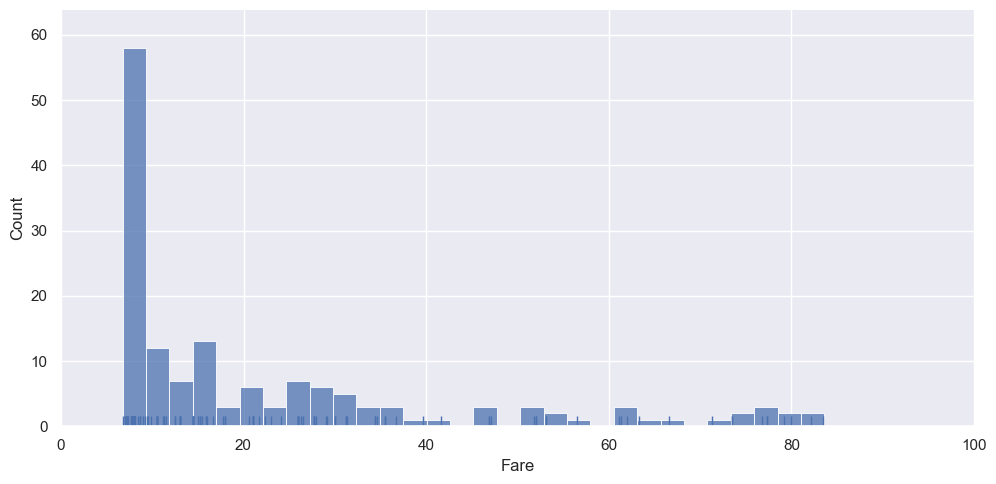

In [12]:
sns.displot(titanic_df["Fare"],
            rug=True,
            bins=100,
            height=5,
            aspect=2)
plt.xlim(0, 100);

#### Boxplot

[Colores de Matplotlib](https://matplotlib.org/3.1.0/gallery/color/named_colors.html)

[Boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

Los boxplots dan una información muy parecida a los gráficos vistos anteriormente, aunque en este caso destaca mucho más los outliers.

In [13]:
p_0 = np.percentile(titanic_df["Fare"], 0) #Q0 #Min
p_25 = np.percentile(titanic_df["Fare"], 25) #Q1
p_50 = np.percentile(titanic_df["Fare"], 50) #Q2 #Mediana
p_75 = np.percentile(titanic_df["Fare"], 75) #Q3
p_100 = np.percentile(titanic_df["Fare"], 100) #Q4 #Max

print("Valor del percentil 0:", p_0)
print("Valor del percentil 25:", p_25)
print("Valor del percentil 50:", p_50)
print("Valor del percentil 75:", p_75)
print("Valor del percentil 100:", p_100)
print("Valor media:", round(titanic_df["Fare"].mean(),2) )

Valor del percentil 0: 6.75
Valor del percentil 25: 8.00315
Valor del percentil 50: 14.4542
Valor del percentil 75: 30.37185
Valor del percentil 100: 263.0
Valor media: 28.11


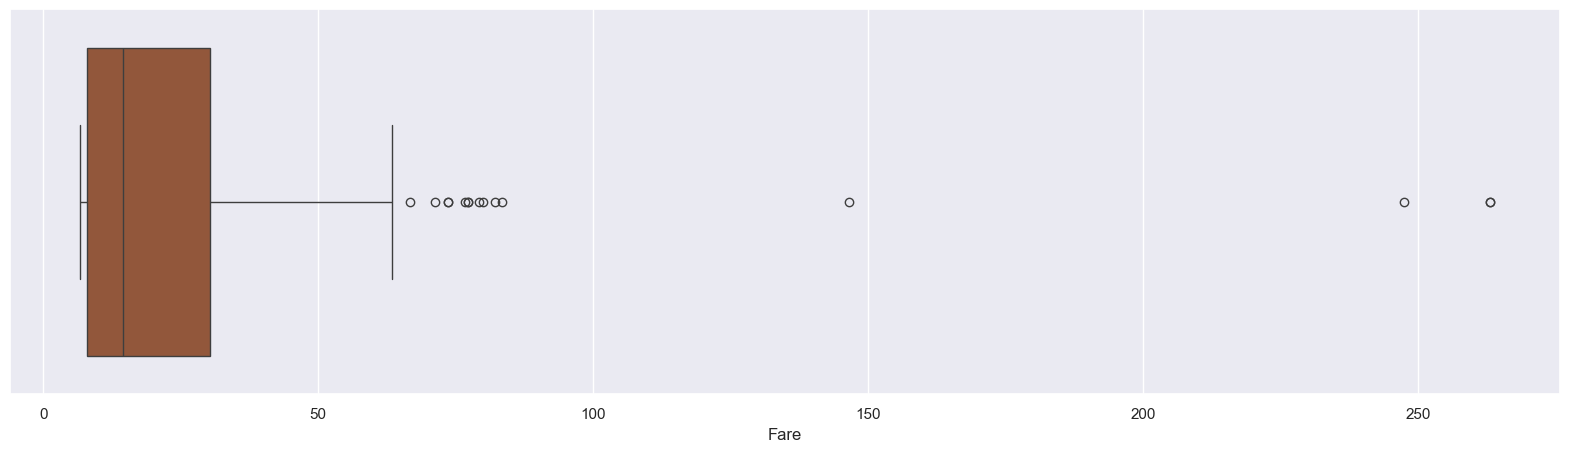

In [16]:
plt.figure(figsize=(20,5))
sns.boxplot(x=titanic_df["Fare"], color="sienna");
#plt.xlim(0,50)

![imagen](./img/boxplot.png)

#### Violinplot

[Colores de Matplotlib](https://matplotlib.org/3.1.0/gallery/color/named_colors.html)

[Violinplot](https://seaborn.pydata.org/generated/seaborn.violinplot.html)

Igual que un diagrama de caja, pero en este caso tiene la función de distribución en lugar de la propia caja

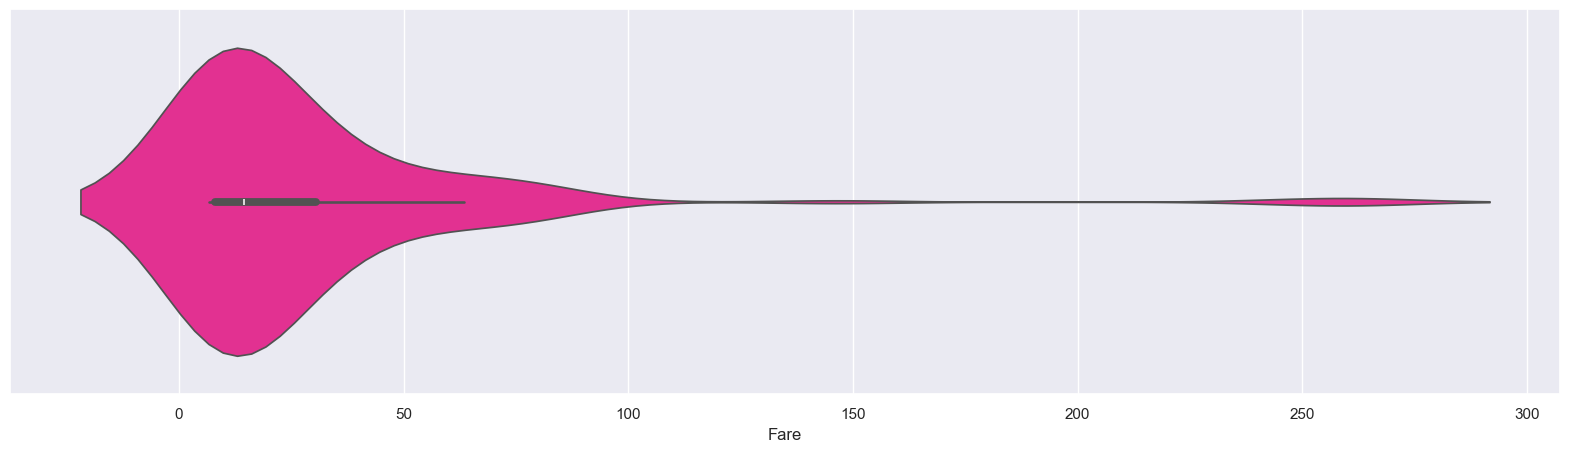

In [17]:
plt.figure(figsize=(20,5))
sns.violinplot(x=titanic_df["Fare"], color='deeppink');

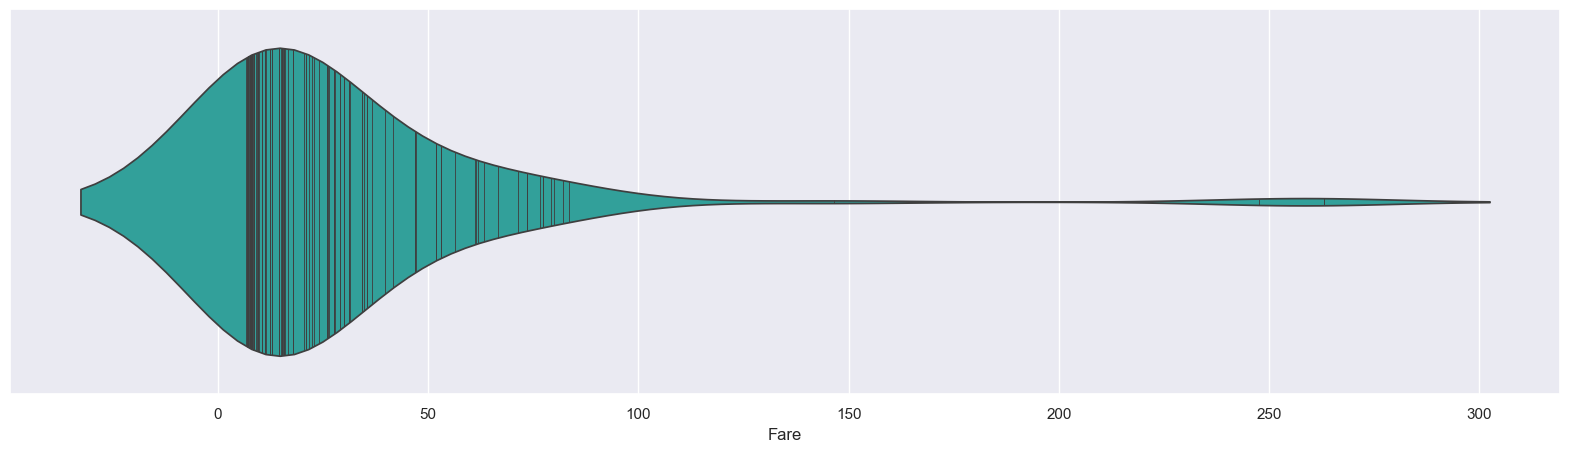

In [25]:
plt.figure(figsize=(20,5))
sns.violinplot(x=titanic_df["Fare"], color='lightseagreen', bw=0.5, inner="stick");

### 1.2 Variables cualitativas
Para representar una variable categórica tendremos que ver su frecuencia de valores

En este caso vamos a ver qué tipo de embarque ha sido el más frecuente.

[Documentacion](https://seaborn.pydata.org/generated/seaborn.countplot.html)

In [19]:
titanic_df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

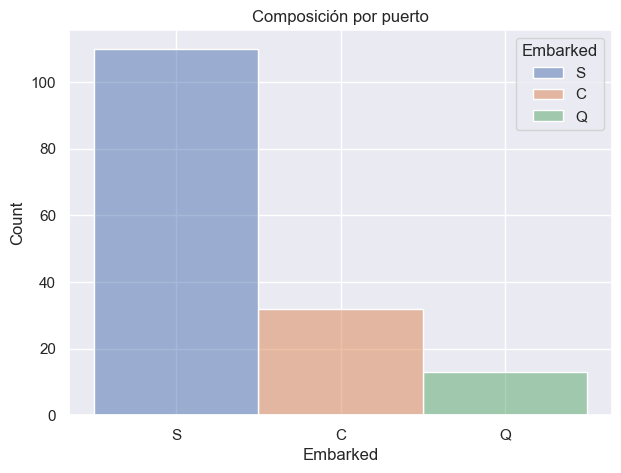

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x=titanic_df["Embarked"], hue=titanic_df["Embarked"]);
plt.title("Composición por puerto");

#### Lollipop

¿Cuáles han sido los productos más pedidos?

[Documentación](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.hlines.html)

In [ ]:
market_df.head()

In [ ]:
market_df['Product line'].value_counts(ascending=False)

In [ ]:
conteo = market_df['Product line'].value_counts(ascending=False)

plt.figure(figsize=(10,5))
plt.hlines(y=conteo.index,
           xmin=150,
           xmax=conteo,
           color='skyblue')
plt.plot(conteo, conteo.index, "o");


#### Donut chart/Pie chart

[Documentación](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.pie.html)

In [ ]:
titanic_df["Embarked"].value_counts()

In [ ]:
import matplotlib.pyplot as plt
 
# create data
data = titanic_df["Embarked"].value_counts()
 
# # Create a circle for the center of the plot
my_circle=plt.Circle( (0,0),
                     0.9, # Grosor del donut
                     color='white')

plt.figure(figsize=(8,8))

plt.pie(data.values,
        labels=data.index,
        autopct='%1.2f%%');

p=plt.gcf()
p.gca().add_artist(my_circle);

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(data.values,
        labels=data.index,
        autopct='%1.2f%%')
p=plt.gcf();

## 2. Análisis Bivariante
### 2.1 Comparativa de variables cuantitativas (2-4 variables)
#### Boxplot

En este ejemplo veremos cómo de diferentes son las distribuciones de las 4 características que definen a una flor.

[Boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

In [ ]:
iris_df.head()

In [ ]:
iris_df.columns.values[0:4]

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=iris_df[iris_df.columns.values[0:4]]);

El boxplot está bien, pero hay algo de información que se nos escapa

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=iris_df[iris_df.columns.values[0:4]])
sns.swarmplot(data=iris_df[iris_df.columns.values[0:4]],
             color="black", edgecolor="gray");

#### Diagramas de densidad

Otra manera de ver cómo se distribuyen las características de las flores.

[Documentación](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)

In [ ]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=iris_df[iris_df.columns.values[0:4]], shade=True);

#### Histogramas

[Documentación](https://seaborn.pydata.org/generated/seaborn.distplot.html)

In [ ]:
sns.displot(iris_df[["sepal length (cm)", "sepal width (cm)"]], kde=True);
# sns.displot(iris_df["sepal width (cm)"] , color="red", label="Sepal Width")
# plt.legend();

In [ ]:
# f, axes = plt.subplots(2, 2, figsize=(15,10), sharex=True)
# sns.distplot(iris_df["sepal length (cm)"] , color="skyblue", ax=axes[0, 0])
# sns.distplot(iris_df["sepal width (cm)"] , color="olive", ax=axes[0, 1])
# sns.distplot(iris_df["petal length (cm)"] , color="gold", ax=axes[1, 0])
# sns.distplot(iris_df["petal width (cm)"] , color="teal", ax=axes[1, 1]);

# Setup the figure and axes
f, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# Update sns.distplot to sns.histplot with kde=True
sns.histplot(iris_df["sepal length (cm)"], color="skyblue", ax=axes[0, 0], kde=True)
sns.histplot(iris_df["sepal width (cm)"], color="olive", ax=axes[0, 1], kde=True)
sns.histplot(iris_df["petal length (cm)"], color="gold", ax=axes[1, 0], kde=True)
sns.histplot(iris_df["petal width (cm)"], color="teal", ax=axes[1, 1], kde=True)

plt.tight_layout()

#### Scatter plot

En este ejemplo se ve claramente cómo estas dos variables sirven para distinguir las setosas de los otros tipos

[Documentación](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

In [ ]:
iris_df.head()

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=iris_df['sepal length (cm)'],
                y=iris_df['sepal width (cm)'],
                hue = iris_df['target'],
               s=100);

[Documentación dataset](https://scikit-learn.org/stable/datasets/index.html#boston-dataset)

[Documentación jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html)

% poblacion con poco poder adquisitivo vs media de habitaciones por vivienda

In [ ]:
sns.jointplot(x=boston_df['LSTAT'],
              y=boston_df['RM'],
              color="#4CB391",
             height = 8);

In [ ]:
sns.jointplot(x=boston_df['LSTAT'],
              y=boston_df['RM'],
              kind="hex",
              color="#4CB391");

In [ ]:
plt.figure(figsize=(8,8))
sns.jointplot(x=boston_df['LSTAT'],
              y=boston_df['RM'],
              kind="kde",
              color="#4CB391");

### 2.2 Comparativa de múltiples numéricas

#### Heatmaps

Los heatmaps son perfectos para representar una matriz de correlación

[Documentación heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

In [ ]:
boston_df.corr().abs().round(2)["MEDV"].sort_values(ascending=False)

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(boston_df.corr().round(2),
            vmin=-1,
            vmax=1,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
            square=True,
            linewidths=.1,
            annot=True);

In [ ]:
# EJEMPLO DE MALA ESCALA DE COLORES
f, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(boston_df.corr(),
            annot=True,
            linewidths=.5,
            ax=ax,
            vmin=-1,
            vmax=1);

También nos permite comparar una variable numérica vs dos variables categóricas. Por ejemplo la cantidad de suicidios desagregado por edades y paises.

Se recomienda que las dos variables categóricas tengan pocos casos, porque si no, no se va a ver bien el heatmap.

In [ ]:
suicid_df.head()

In [ ]:
data = suicid_df.groupby(['country', 'age']).sum()['suicides_no']
data

In [ ]:
data = suicid_df.groupby(['country', 'age']).sum()['suicides_no'].unstack()
data = data.loc[['Italy', 'Spain', 'Portugal', 'Belgium', 'Czech Republic']]

In [ ]:
data

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data,
            square=True,
            linewidths=.3,
            annot=True);

#### Correlograma

[Documentación Pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)

Interesante gráfica para ver en un dataset qué variables presentan correlación lineal, así como sus distribuciones. NO realices esta gráfica con muchas variables porque no se va a ver bien. Hazlo por partes.

In [ ]:
# plt.figure(figsize=(6,6))
sns.pairplot(iris_df);

In [ ]:
sns.pairplot(iris_df,
             kind="scatter",
             hue="target",
             plot_kws=dict(s=80, edgecolor="white",
                           linewidth=2.5));

In [ ]:
sns.pairplot(iris_df,
             kind="scatter",
             hue="target",
             diag_kind="hist");

### 2.3 Comparativa de dos variables cualitativas
#### Tabla

[Documentacion](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html)

Lo más sencillo, una tabla con la frecuencia de valores. Esto es factible cuando los elementos únicos por categoría no son muchos.

In [ ]:
pd.crosstab(titanic_df["Embarked"],
            titanic_df["Sex"],
            margins = True) 

#### Diagrama de barras

[Documentacion](https://seaborn.pydata.org/generated/seaborn.catplot.html)

En un diagrama de barras también se entiende la representación de dos variables cualitativas

In [ ]:
sns.catplot(x="Embarked",
            hue="Sex",
            kind="count",
            edgecolor=".6",
            orient = "V",
            data=titanic_df);

Otra manera de visualizar dos o más variables categóricas

In [ ]:
sns.catplot(x="Survived",
            col="Embarked",
            col_wrap=3,
            data=titanic_df,
            kind="count");

In [ ]:
titanic_df.groupby(['Embarked','Sex'])['Survived'].sum()

In [ ]:
sns.catplot(x="Sex",
            y="Survived",
            hue="Embarked",
            kind="bar",
            data=titanic_df,
            ci=None); # Para que elimine las barras de error

In [ ]:
df_plot = titanic_df.groupby(['Embarked', 'Survived']).size().reset_index().pivot(columns='Embarked',
                                                                                  index='Survived',
                                                                                  values=0)
df_plot.plot(kind='bar', stacked=True);
#df_plot

### 2.4 Cualitativa vs cuantitativa
#### Time series

[Documentacion](https://seaborn.pydata.org/generated/seaborn.lineplot.html)

Las series temporales tienen la particularidad de que son datos ordenados

In [ ]:
suicid_df2 = suicid_df[suicid_df['country'].isin(['Spain', 'Germany', 'France'])]
suicid_df2 = suicid_df2.groupby(['country', 'year']).sum()
suicid_df2
suicid_df2.reset_index(inplace=True)
suicid_df2

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(data=suicid_df2,
             x="year",
             y="suicides_no",
             hue="country",
            linewidth = 3);

#### Treemap
Un treemap es una opción muy interesante para mostrar una variable numérica vs una categórica

In [ ]:
suicid_df.groupby("country").sum()['suicides_no'].sort_values(ascending=False)[:30]

In [ ]:
# %pip install squarify

In [ ]:
import squarify

data = suicid_df.groupby("country").sum()['suicides_no'].sort_values(ascending=False)[:10]

plt.figure(figsize=(10,8))
squarify.plot(sizes=data.values, label=data.index, alpha=.8 )
plt.axis('off')
plt.title("Suicidios por país")
plt.show()

Con este catplot obtenemos la dispersión de la variable Age, por cada grupo de la categoría.

In [ ]:
sns.catplot(x="Survived", y="Age", hue="Sex", data=titanic_df);

El equivalente con un diagrama de caja sería el siguiente

In [ ]:
titanic_df.info()

In [ ]:
# titanic_df['Survived_string'] = np.where(titanic_df['Survived']==1, 'Superviviente', 'No superviviente')
# titanic_df.head()

In [ ]:
sns.catplot(x="Survived", y="Age", hue="Sex", kind="box", data=titanic_df,col="Embarked");

In [ ]:
sns.catplot(x="Survived", y="Age", hue="Sex", kind="violin", data=titanic_df);

In [ ]:
sns.catplot(x="Survived", y="Age", hue="Sex", kind="violin", split=True, data=titanic_df);

In [ ]:
sns.catplot(x="City", y="Total", kind="swarm", data=market_df);

In [ ]:
sns.catplot(x="Survived",
            y="Fare",
            hue="Sex",
            col="Embarked",
            data=titanic_df,
            height=5,
            aspect=.8);

In [ ]:
suicid_df2 = suicid_df[suicid_df['country'].isin(['Spain', 'Germany', 'France', 'Japan'])]

chart = sns.catplot(x="age",
            y="suicides/100k pop",
            hue="sex",
            col="country",
            data=suicid_df2,
            height=8,
            aspect=.8)
chart.set_xticklabels(rotation=45);

In [ ]:
sns.catplot(x="Fare",
            y="Embarked",
            hue="Sex",
            kind="violin",
            col="Survived",
            bw=.1,
            height=8,
            aspect=.8,
            data=titanic_df);

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(
   data=titanic_df, x="Fare", hue="Embarked",
   fill=True, common_norm=False,
   alpha=.5, linewidth=0,
);

In [ ]:
suicid_df2 = suicid_df[suicid_df['country'] == 'Spain']

plt.figure(figsize=(20,8))
sns.barplot(x="year",
            y="suicides_no",
            palette="Blues_d",
            data=suicid_df2,
           ci=None);

In [ ]:
# Filter countries with 'gdp_per_capita > 10000
df1 = suicid_df.groupby('country').sum()['suicides_no']
df2 = suicid_df[suicid_df['gdp_per_capita ($)'] > 10000].groupby('country').sum()['suicides_no']
df1 = df1[df1.index.isin(df2.index)]

df_tot = pd.DataFrame({"Tot_suicide": df1, "Suicide_gdp": df2}).sort_values("Tot_suicide", ascending=False)[:20]
df_tot.reset_index(level=0, inplace=True)

In [ ]:
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))

# Plot the total crashes
sns.set_color_codes("pastel")
sns.barplot(x="Tot_suicide", y="country", data=df_tot,
            label="Total", color="b")

# Plot the crashes where alcohol was involved
sns.set_color_codes("muted")
sns.barplot(x="Suicide_gdp", y="country", data=df_tot,
            label="High gdp", color="b")

# Add a legend and informative axis label
ax.legend(ncol=2, loc="lower right", frameon=True)
sns.despine(left=True, bottom=True)

#### Bubble chart

In [ ]:
suicid_df[suicid_df['country-year'] == 'Spain2002']

In [ ]:
suicid_df2 = suicid_df[suicid_df['country-year'] == 'Spain2002']

sns.relplot(data=suicid_df2,
            x="suicides_no",
            y="suicides/100k pop",
            hue="sex", size="age",
            sizes=(4, 300),
            alpha=.5, palette="muted",
            height=6);

In [ ]:
suicid_df2 

## 3. Gráficos de Radar (Radar Charts)
El gráfico de radar es útil para comparar múltiples variables cuantitativas que tienen la misma escala. Es muy común en análisis de perfiles (por ejemplo, habilidades de un empleado o estadísticas de un jugador).

Se basa en un eje radial (circular) donde cada radio representa una variable diferente.

[Documentación de apoyo (Matplotlib Polar)](https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_demo.html)

#### 

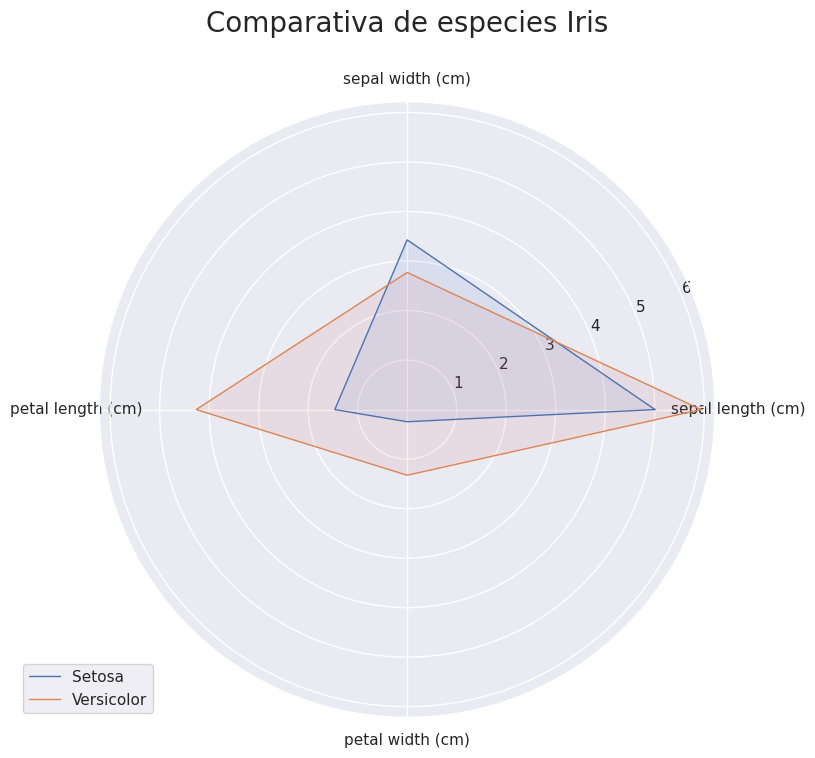

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparamos los datos: calculamos la media por especie
categories = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
N = len(categories)

# Obtenemos las medias para dos especies: Setosa y Versicolor
setosa_values = iris_df[iris_df['target'] == 'setosa'][categories].mean().values.tolist()
versicolor_values = iris_df[iris_df['target'] == 'versicolor'][categories].mean().values.tolist()

# El gráfico debe ser circular, así que "cerramos" el bucle repitiendo el primer valor al final
setosa_values += setosa_values[:1]
versicolor_values += versicolor_values[:1]

# 2. Calculamos los ángulos de cada eje
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 3. Inicializamos el gráfico radial
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Dibujamos un eje por cada variable y añadimos etiquetas
plt.xticks(angles[:-1], categories)

# 4. Dibujamos los datos
# Especie Setosa
ax.plot(angles, setosa_values, linewidth=1, linestyle='solid', label="Setosa")
ax.fill(angles, setosa_values, 'b', alpha=0.1)

# Especie Versicolor
ax.plot(angles, versicolor_values, linewidth=1, linestyle='solid', label="Versicolor")
ax.fill(angles, versicolor_values, 'r', alpha=0.1)

# Añadimos leyenda y título
plt.title("Comparativa de especies Iris", size=20, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.show()